# Vision - Language Models (VLMs)

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import requests
from io import BytesIO
import json
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [2]:
%pip install open-clip-torch

  Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl.metadata (4.1 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 6.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 14.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 10.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 13.3 MB/s  0:00:00 eta 0:00:01
Using cached shellingham-1.5.4-py2.py3-none-any.whl (9.8 kB)
Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl (447 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15/15 [open-clip-torch] [open-clip-torch]
Note: you may need to restart the kernel to use updated packages.


In [6]:
plt.style.use('default')
import seaborn as sns
sns.set_palette("deep")
from open_clip import create_model_and_transforms, get_tokenizer

## Setting Up CLIP

In [14]:
# We define a class wrapper to handle CLIP operations
class CLIPExplorer:
    def __init__(self, model_name="ViT-B-32", pretrained="laion2b_s34b_b79k"):

        # Define available device
        if torch.cuda.is_available():
            self.device = torch.device("cuda")
        elif torch.backends.mps.is_available():
            self.device = torch.device("mps")
        else:
            self.device = torch.device("cpu")
        print(f"Using device: {self.device}")

        # CLIP contains two different submodels: an image encoder (often a Vision Transformer)
        # and a text encoder (standard transformer)
        #
        # open_clip hands use the models, and also the image preprocessing pipeline (how to resize, crop,
        # normalize images exactly how the model expects) and a tokenizer (how to chop words up into numerical
        # token IDs that the text encoder can read).

        # Load model and preprocessor
        self.model, _, self.image_preprocess = create_model_and_transforms(model_name, pretrained=pretrained)
        self.tokenizer = get_tokenizer(model_name)

        # Move model to the right device and set it to the right mode (evaluation)
        self.model.to(self.device)
        self.model.eval()

        # Get confirmation message
        print(f"Loaded CLIP model: {model_name}")

    # This method extracts features from images
    def encode_images(self, images):
        if isinstance(images, Image.Image):
            images = [images]
        images = [self.image_preprocess(img).unsqueeze(0) for img in images]
        images = torch.cat(images).to(self.device)

        with torch.no_grad():
            # Extract features using the encode_image method of the model
            image_features = self.model.encode_image(images)

            # Normalize (use F.normalize)
            image_features = F.normalize(image_features, p=2, dim=1)
        return image_features.cpu().numpy()

    # This method extracts features from text
    def encode_texts(self, texts):
        if isinstance(texts, str):
            texts = [texts]
        texts = self.tokenizer(texts).to(self.device)

        with torch.no_grad():
            # Extract text features using model.encode_text
            text_features = self.model.encode_text(texts)

            # Normalize
            text_features = F.normalize(text_features, p=2, dim=1)
        return text_features.cpu().numpy()

    # Define method computing cosine similarity between image ambeddings and text embeddings
    def compute_similarity(self, image_embeds, text_embeds):
        return cosine_similarity(image_embeds, text_embeds)

    # Define a method performing zero-shot classification
    def zero_shot_classify(self, image, class_names, template="A photo of a {}"):
        text_prompts = [template.format(class_name) for class_name in class_names]

        # Encode the given image
        image_embed = self.encode_images([image])

        # Encode given prompts
        text_embeds = self.encode_texts(text_prompts)

        # Compute similarities (this will return a vector, keep only the first element)
        similarities = self.compute_similarity(image_embed, text_embeds)

        # Take predicted index by computing argmax over similarities
        predicted_idx = np.argmax(similarities)

        return {
            'predicted_class': class_names[predicted_idx],
            'confidence': similarities[0, predicted_idx],
            'all_scores': dict(zip(class_names, similarities[0]))
        }

# Instantiate the model
clip_explorer = CLIPExplorer()

Using device: mps
Loaded CLIP model: ViT-B-32


## Data Loading

Loaded 5 sample images


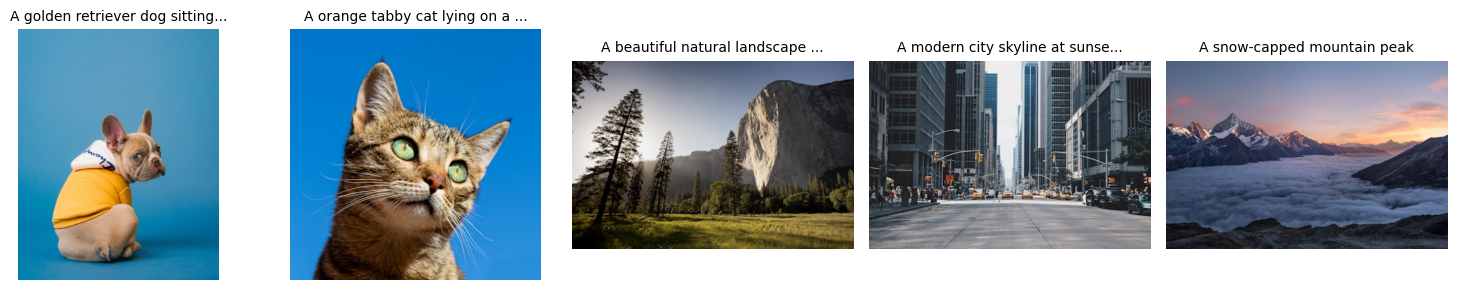

In [15]:
def load_sample_images():
    image_urls = [
        "https://images.unsplash.com/photo-1583337130417-3346a1be7dee?w=400",
        "https://images.unsplash.com/photo-1574158622682-e40e69881006?w=400",
        "https://images.unsplash.com/photo-1426604966848-d7adac402bff?w=400",
        "https://images.unsplash.com/photo-1449824913935-59a10b8d2000?w=400",
        "https://images.unsplash.com/photo-1506905925346-21bda4d32df4?w=400",
    ]
    images = []
    descriptions = [
        "A golden retriever dog sitting in grass",
        "A orange tabby cat lying on a bed",
        "A beautiful natural landscape with trees",
        "A modern city skyline at sunset",
        "A snow-capped mountain peak"
    ]
    for i, url in enumerate(image_urls):
        try:
            response = requests.get(url, timeout=10)
            img = Image.open(BytesIO(response.content)).convert('RGB')
            images.append(img)
        except:
            print(f"Could not load image {i+1}, using placeholder")
            img = Image.new('RGB', (400, 400), color=(100*i, 150, 200))
            images.append(img)
    return images, descriptions

sample_images, sample_descriptions = load_sample_images()
print(f"Loaded {len(sample_images)} sample images")
fig, axes = plt.subplots(1, len(sample_images), figsize=(15, 3))
for i, (img, desc) in enumerate(zip(sample_images, sample_descriptions)):
    axes[i].imshow(img)
    axes[i].set_title(desc[:30] + "..." if len(desc) > 30 else desc, fontsize=10)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## CLIP Operations

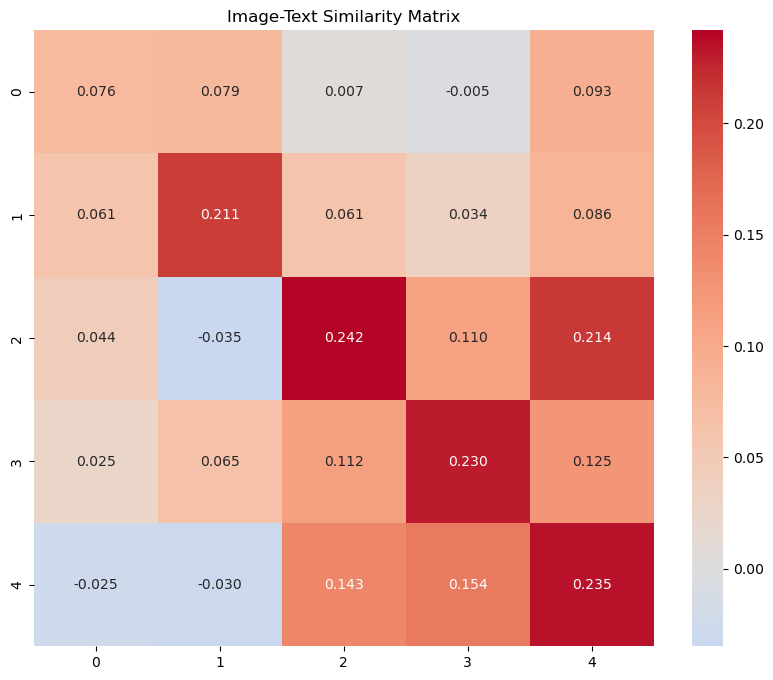

Image 1 matches Text 5 (score: 0.093)
Image 2 matches Text 2 (score: 0.211)
Image 3 matches Text 3 (score: 0.242)
Image 4 matches Text 4 (score: 0.230)
Image 5 matches Text 5 (score: 0.235)


In [16]:
# Extract images embeddings
image_embeddings = clip_explorer.encode_images(sample_images)

# Extract text embeddings
text_embeddings = clip_explorer.encode_texts(sample_descriptions)

# Compute similarity scores between images embeddings and text embeddings
similarity_matrix = clip_explorer.compute_similarity(image_embeddings, text_embeddings)

# Plot similarity matrix
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0)
plt.title('Image-Text Similarity Matrix')
plt.show()

# Find best matches
for i in range(len(image_embeddings)):
    best_idx = np.argmax(similarity_matrix[i])
    print(f"Image {i+1} matches Text {best_idx+1} (score: {similarity_matrix[i, best_idx]:.3f})")

## Zero-Shot Classification

In [17]:
# Define some classes
animal_classes = ["dog", "cat", "bird"]
scene_classes = ["mountain", "beach", "forest"]

def test_classification(image_idx, class_names, category_name):
    result = clip_explorer.zero_shot_classify(sample_images[image_idx], class_names)
    print(f"{category_name} Classification for Image {image_idx + 1}: {result['predicted_class']} ({result['confidence']:.3f})")
    return result

test_classification(0, animal_classes, "Animal")
test_classification(2, scene_classes, "Scene")

Animal Classification for Image 1: dog (0.264)
Scene Classification for Image 3: mountain (0.276)


{'predicted_class': 'mountain',
 'confidence': np.float32(0.27593112),
 'all_scores': {'mountain': np.float32(0.27593112),
  'beach': np.float32(0.17960161),
  'forest': np.float32(0.22705121)}}

## Image Retrieval System

In [19]:
class ImageRetrievalSystem:
    def __init__(self, clip_explorer):
        # Clip model
        self.clip_explorer = clip_explorer
        # Collection of images (database)
        self.image_database = []
        # Image embeddings
        self.image_embeddings = None
        # Metadata: optional additional text information attached to images
        # to help identify or label them
        self.image_metadata = []

    # This method allows for the contruction of a database
    def add_images(self, images, metadata=None):
        # Add to the database the given images
        self.image_database.extend(images)

        # Add metadata. If missing assign a default string
        if metadata is None:
            metadata = [f"Image_{i}" for i in range(len(images))]
        self.image_metadata.extend(metadata)

        # Get images embeddings and add them to existing ones (for images already
        # in the database)
        new_embeddings = self.clip_explorer.encode_images(images)
        self.image_embeddings = new_embeddings if self.image_embeddings is None else np.vstack([self.image_embeddings, new_embeddings])

    def search(self, query_text, top_k=3):
        # Encode the query prompts
        query_embedding = self.clip_explorer.encode_texts([query_text])

        # Compute similarity scores between prompts embeddings and images embeddings
        similarities = cosine_similarity(query_embedding, self.image_embeddings)[0]

        top_indices = np.argsort(similarities)[::-1][:top_k]
        return [{'image': self.image_database[i], 'similarity': similarities[i]} for i in top_indices]

# Instantiate the model
retrieval_system = ImageRetrievalSystem(clip_explorer)

# Populate database
retrieval_system.add_images(sample_images, metadata=sample_descriptions)

# Test retrieval
test_queries = ["a cute dog", "urban landscape"]
for query in test_queries:
    results = retrieval_system.search(query)
    print(f"Results for '{query}': {[r['similarity'] for r in results]}")

Results for 'a cute dog': [np.float32(0.26567656), np.float32(0.16812986), np.float32(0.0802458)]
Results for 'urban landscape': [np.float32(0.25685093), np.float32(0.123400174), np.float32(0.1120531)]
